# Setting up a NanoGPT-style transformer

## Basic setups (dataloader, configs, etc)

### Config

First, we start with the configs for our training and model step. I used the configs that I found from the original Transformer and NanoGPT implementations, more or less.

In [1]:
from dataclasses import dataclass
import torch


@dataclass
class TrainConfig:
    batch_size: int = 64
    block_size: int = 128
    max_epochs: int = 5000
    eval_interval: int = 250
    eval_iters: int = 100
    learning_rate: float = 3e-4
    weight_decay: float = 0.1
    beta1: float = 0.9
    beta2: float = 0.95
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0.1
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42


@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True


### Dataloader

Next, we set up a `Dataloader`. This produces the train/validation batches for our training. For simplicity, we use the same character-based tokenization approach that was in the original NanoGPT implementation.

In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Literal
import urllib.request

import torch

TINY_SHAKESPEARE_URL = (
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
)


class Dataloader:
    """Loads Tiny Shakespeare and serves train/val autoregressive batches."""

    def __init__(
        self,
        dataset_path: Path,
        batch_size: int,
        block_size: int,
        device: str,
        train_split_ratio: float = 0.9,
    ) -> None:
        self.dataset_path = dataset_path
        self.batch_size = batch_size
        self.block_size = block_size
        self.device = device
        self.train_split_ratio = train_split_ratio

        self._ensure_tiny_shakespeare()
        text = self.dataset_path.read_text(encoding="utf-8")
        self.stoi, self.itos = self._build_vocab(text)
        self.data = torch.tensor(self.encode(text), dtype=torch.long)

        split_index = int(self.train_split_ratio * len(self.data))
        self.train_data = self.data[:split_index]
        self.val_data = self.data[split_index:]

    @property
    def vocab_size(self) -> int:
        return len(self.stoi)

    @property
    def train_tokens(self) -> int:
        return int(self.train_data.numel())

    @property
    def val_tokens(self) -> int:
        return int(self.val_data.numel())

    def _ensure_tiny_shakespeare(self) -> None:
        self.dataset_path.parent.mkdir(parents=True, exist_ok=True)
        if self.dataset_path.exists():
            return
        print(f"Downloading Tiny Shakespeare dataset to {self.dataset_path}...")
        urllib.request.urlretrieve(TINY_SHAKESPEARE_URL, self.dataset_path)

    @staticmethod
    def _build_vocab(text: str) -> tuple[dict[str, int], dict[int, str]]:
        chars = sorted(set(text))
        stoi = {ch: i for i, ch in enumerate(chars)}
        itos = {i: ch for i, ch in enumerate(chars)}
        return stoi, itos

    def encode(self, text: str) -> list[int]:
        return [self.stoi[ch] for ch in text]

    def decode(self, token_ids: list[int]) -> str:
        return "".join(self.itos[i] for i in token_ids)

    def get_batch(self, split: Literal["train", "val"]) -> tuple[torch.Tensor, torch.Tensor]:
        data = self.train_data if split == "train" else self.val_data
        ix = torch.randint(len(data) - self.block_size, (self.batch_size,))
        x = torch.stack([data[i : i + self.block_size] for i in ix])
        y = torch.stack([data[i + 1 : i + self.block_size + 1] for i in ix])
        return x.to(self.device), y.to(self.device)

## Setting up the Model

Next, we set up the Transformer model. We use a decoder-only architecture with causal self-attention. We make it a multi-head approach, with `n_head=4`.

### Model details

The model has the following implementation details, largely inspired by both NanoGPT and the original transformers implementation:

- Model type: decoder-only GPT
- Transformer depth (n_layer): 4 blocks.
- Attention heads (n_head): 4 heads per block.
- Embedding dimension (n_embd): 128.
- Context length (block_size): 128 tokens.
- Tokenization: character-level vocabulary built from dataset characters.
- Dropout: 0.1 (embeddings/attention/MLP residual paths).
- Normalization: pre-LayerNorm block structure + final LayerNorm.
- Block internals: masked multi-head self-attention + MLP (128 -> 512 -> 128) with residual connections.
- LM head: linear projection to vocab with weight tying to token embeddings.

In [3]:
from __future__ import annotations

import inspect
import math

import torch
import torch.nn as nn
from torch.nn import functional as F

class LayerNorm(nn.Module):
    """LayerNorm with optional bias for GPT-2 parity.

    GPT-2 didn't have it, according to NanoGPT, but the PyTorch
    implementation does. So we're going to keep it optional."""

    def __init__(self, ndim: int, bias: bool) -> None:
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)


class MultiAttentionHead(nn.Module):
    """Projects hidden states to multi-head Q/K/V and merges heads back."""

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        if config.n_embd % config.n_head != 0:
            raise ValueError("n_embd must be divisible by n_head")
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.head_size = config.n_embd // config.n_head
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)

    def project_qkv(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Projects the input tensor `x` to Q, K, and V tensors."""
        bsz, seq_len, _ = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(bsz, seq_len, self.n_head, self.head_size).transpose(1, 2)
        q = q.view(bsz, seq_len, self.n_head, self.head_size).transpose(1, 2)
        v = v.view(bsz, seq_len, self.n_head, self.head_size).transpose(1, 2)
        return q, k, v

    def merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """Merges the heads of the input tensor `x`."""
        bsz, _, seq_len, _ = x.size()
        return x.transpose(1, 2).contiguous().view(bsz, seq_len, self.n_embd)


class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention."""

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.multi_head = MultiAttentionHead(config)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.dropout = config.dropout
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size)).view(
                1, 1, config.block_size, config.block_size
            ),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, seq_len, _ = x.size()
        q, k, v = self.multi_head.project_qkv(x)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.multi_head.head_size))

        # add causal mask to the attention scores
        att = att.masked_fill(self.bias[:, :, :seq_len, :seq_len] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v

        y = self.multi_head.merge_heads(y)
        return self.resid_dropout(self.c_proj(y))


class MLP(nn.Module):
    """Position-wise feed-forward network."""

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return self.dropout(x)


class TransformerBlock(nn.Module):
    """Pre-norm transformer block with residual connections."""

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class GPT(nn.Module):
    """Decoder-only GPT language model."""

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        if config.vocab_size is None or config.block_size is None:
            raise ValueError("vocab_size and block_size must be set")
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte=nn.Embedding(config.vocab_size, config.n_embd),
                wpe=nn.Embedding(config.block_size, config.n_embd),
                drop=nn.Dropout(config.dropout),
                h=nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layer)]),
                ln_f=LayerNorm(config.n_embd, bias=config.bias),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith("c_proj.weight"):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def get_num_params(self, non_embedding: bool = True) -> int:
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def forward(
        self, idx: torch.Tensor, targets: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        device = idx.device
        _, seq_len = idx.size()
        if seq_len > self.config.block_size:
            raise ValueError(
                f"Cannot forward sequence of length {seq_len}, block size is only {self.config.block_size}"
            )

        # build position indices
        pos = torch.arange(0, seq_len, dtype=torch.long, device=device)

        # do token embedding lookup for each position, getting the embedding
        # tensor for each position
        tok_emb = self.transformer.wte(idx)

        # do positional embedding lookup for each position, getting the embedding
        # tensor for each position
        pos_emb = self.transformer.wpe(pos)

        # adds position embeddings to token embeddings. also applies dropout.
        x = self.transformer.drop(tok_emb + pos_emb)

        # apply each transformer block to the input
        for block in self.transformer.h:
            x = block(x)

        # final layer normalization
        x = self.transformer.ln_f(x)

        # apply the linear head project
        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1
            )
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None

        return logits, loss

    def configure_optimizers(
        self,
        weight_decay: float,
        learning_rate: float,
        betas: tuple[float, float],
        device_type: str,
    ) -> torch.optim.Optimizer:
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}
        decay_params = [p for _, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for _, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {"params": decay_params, "weight_decay": weight_decay},
            {"params": nodecay_params, "weight_decay": 0.0},
        ]

        fused_available = "fused" in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == "cuda"
        extra_args = {"fused": True} if use_fused else {}
        return torch.optim.AdamW(
            optim_groups, lr=learning_rate, betas=betas, **extra_args
        )

    @torch.no_grad()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        for _ in range(max_new_tokens):
            idx_cond = (
                idx
                if idx.size(1) <= self.config.block_size
                else idx[:, -self.config.block_size :]
            )
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < values[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx


## Setting up the training logic

Here we include the training logic as well.

In [4]:
import sys
!{sys.executable} -m pip install wandb

### Creating a `Trainer` class

In [5]:
import argparse
import json
from dataclasses import asdict, dataclass
from datetime import datetime
from pathlib import Path
import wandb

@dataclass
class LossEvent:
    epoch: int
    train_loss: float
    val_loss: float
    wall_time: str

class GptTrainer:
    def __init__(
        self,
        cfg: TrainConfig,
        dataloader: Dataloader,
        output_dir: Path,
        dataset_path: Path,
        use_wandb: bool = False,
    ) -> None:
        """Initializes the GPT trainer."""
        self.cfg = cfg
        self.dataloader = dataloader
        self.output_dir = output_dir
        self.dataset_path = dataset_path
        self.history: list[LossEvent] = []
        self.use_wandb = use_wandb

        model_cfg = GPTConfig(
            block_size=cfg.block_size,
            vocab_size=dataloader.vocab_size,
            n_layer=cfg.n_layer,
            n_head=cfg.n_head,
            n_embd=cfg.n_embd,
            dropout=cfg.dropout,
        )
        self.model_cfg = model_cfg
        self.model = GPT(model_cfg).to(cfg.device)
        self.optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=cfg.learning_rate,
            betas=(cfg.beta1, cfg.beta2),
            weight_decay=cfg.weight_decay,
        )

        if self.use_wandb:
            wandb.init(project="nanogpt_finetune", config=asdict(self.cfg))
            wandb.watch(self.model)

    @torch.no_grad()
    def estimate_loss(self) -> dict[str, float]:
        """Esimating the loss. Computing exact loss over the entire dataset is
        expensive and we do this for logging purposes anyways. Instead,
        we do random Monte-Carlo style estimates from random mini-batches.
        """
        self.model.eval()

        train_losses = torch.zeros(self.cfg.eval_iters)
        for eval_iter in range(self.cfg.eval_iters):
            batch_x, batch_y = self.dataloader.get_batch(split="train")
            _, loss = self.model(batch_x, batch_y)
            if loss is None:
                raise RuntimeError("Loss should not be None during train evaluation.")
            train_losses[eval_iter] = loss.item()

        val_losses = torch.zeros(self.cfg.eval_iters)
        for eval_iter in range(self.cfg.eval_iters):
            batch_x, batch_y = self.dataloader.get_batch(split="val")
            _, loss = self.model(batch_x, batch_y)
            if loss is None:
                raise RuntimeError("Loss should not be None during val evaluation.")
            val_losses[eval_iter] = loss.item()

        self.model.train()
        return {
            "train": train_losses.mean().item(),
            "val": val_losses.mean().item(),
        }

    def save_run_metadata(self) -> None:
        """Exports run metadata to the output directory."""
        metadata = {
            "train_config": asdict(self.cfg),
            "model_config": asdict(self.model_cfg),
            "dataset_path": str(self.dataset_path),
            "output_dir": str(self.output_dir),
            "vocab_size": self.dataloader.vocab_size,
            "train_tokens": self.dataloader.train_tokens,
            "val_tokens": self.dataloader.val_tokens,
        }
        run_config_path = self.output_dir / "run_config.json"

        run_config_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
        if self.use_wandb:
            wandb.config.update(metadata)

    def evaluate_and_log_epoch(self, epoch: int) -> None:
        """Runs periodic evaluation, appends metrics, and prints status."""
        losses = self.estimate_loss()
        event = LossEvent(
            epoch=epoch,
            train_loss=losses["train"],
            val_loss=losses["val"],
            wall_time=datetime.now().isoformat(timespec="seconds"),
        )
        self.history.append(event)
        print(
            f"epoch {epoch:5d} | train loss {event.train_loss:.4f} | "
            f"val loss {event.val_loss:.4f}"
        )
        if self.use_wandb:
            wandb.log({"train_loss": event.train_loss, "val_loss": event.val_loss}, step=epoch)

    def train(self) -> None:
        """Trains the model."""
        self.save_run_metadata()

        print(f"Output directory: {self.output_dir}")
        print(
            f"Training on {self.cfg.device} with vocab_size={self.dataloader.vocab_size}, "
            f"train_tokens={self.dataloader.train_tokens}, val_tokens={self.dataloader.val_tokens}"
        )

        total_epochs = self.cfg.max_epochs + 1

        for epoch in range(total_epochs):

            if epoch % self.cfg.eval_interval == 0 or epoch == self.cfg.max_epochs:
                self.evaluate_and_log_epoch(epoch)

            batch_x, batch_y = self.dataloader.get_batch(split="train")
            _, loss = self.model(batch_x, batch_y)
            if loss is None:
                raise RuntimeError("Loss should not be None during training.")

            self.optimizer.zero_grad(set_to_none=True)
            loss.backward()
            self.optimizer.step()

        loss_history_path = self.output_dir / "loss_history.json"
        loss_history_path.write_text(json.dumps([asdict(event) for event in self.history], indent=2), encoding="utf-8")

        output_model_path = self.output_dir / "model.pt"
        torch.save(self.model.state_dict(), output_model_path)
        print(f"Training complete. Saved model and logs to {output_model_path}")
        if self.use_wandb:
            wandb.finish()

### Running training

We now run the training and review the results

In [6]:
import os

def make_output_dir(root_dir: str) -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = Path(root_dir) / f"run_{timestamp}"
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir

# Local I/O paths
dataset_path = Path("data") / "tinyshakespeare.txt"
output_root = "runs"

cfg = TrainConfig()
torch.manual_seed(cfg.seed)

dataloader = Dataloader(
    dataset_path=dataset_path,
    batch_size=cfg.batch_size,
    block_size=cfg.block_size,
    device=cfg.device,
)

output_dir = make_output_dir(output_root)

trainer = GptTrainer(
    cfg=cfg,
    dataloader=dataloader,
    output_dir=output_dir,
    dataset_path=dataset_path,
    use_wandb=True, # Enable Weights and Biases logging
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: markptorres1 (mind_technology_lab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Output directory: runs/run_20260422_194558
Training on cuda with vocab_size=65, train_tokens=1003854, val_tokens=111540
epoch     0 | train loss 4.1999 | val loss 4.1984
epoch   250 | train loss 2.4187 | val loss 2.4198
epoch   500 | train loss 2.2566 | val loss 2.2798
epoch   750 | train loss 2.0981 | val loss 2.1405
epoch  1000 | train loss 1.9599 | val loss 2.0349
epoch  1250 | train loss 1.8600 | val loss 1.9650
epoch  1500 | train loss 1.7790 | val loss 1.9145
epoch  1750 | train loss 1.7254 | val loss 1.8707
epoch  2000 | train loss 1.6666 | val loss 1.8279
epoch  2250 | train loss 1.6262 | val loss 1.7994
epoch  2500 | train loss 1.5942 | val loss 1.7640
epoch  2750 | train loss 1.5641 | val loss 1.7358
epoch  3000 | train loss 1.5347 | val loss 1.7200
epoch  3250 | train loss 1.5144 | val loss 1.6973
epoch  3500 | train loss 1.4996 | val loss 1.6820
epoch  3750 | train loss 1.4822 | val loss 1.6712
epoch  4000 | train loss 1.4633 | val loss 1.6475
epoch  4250 | train loss 1.450

train_loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_loss,1.41474
val_loss,1.60946


### Review model generations

Now that we've got a trained model, let's look at how the trained model looks

In [7]:
import torch

# Put the model in evaluation mode
trainer.model.eval()

# 5 sample strings to start the generation
sample_strings = [
    "O Romeo, Romeo! wherefore",
    "To be, or not to be, ",
    "Friends, Romans, countrymen,",
    "Now is the winter of our",
    "The lady doth protest too"
]

print("--- Model Generations ---")
for prompt in sample_strings:
    # Encode the string into token ids and move to the correct device
    encoded_prompt = trainer.dataloader.encode(prompt)
    idx = torch.tensor(encoded_prompt, dtype=torch.long, device=cfg.device).unsqueeze(0)

    # Generate 50 new tokens
    max_new_tokens = 50
    generated_idx = trainer.model.generate(idx, max_new_tokens=max_new_tokens)

    # The generate method returns the concatenated original prompt + new tokens.
    # We slice out just the newly generated tokens.
    new_tokens = generated_idx[0, -max_new_tokens:].tolist()

    # Decode the new tokens back to a string
    generated_text = trainer.dataloader.decode(new_tokens)

    # Print the result in the requested format
    print(f"{prompt}...{generated_text}")
    print("-" * 40)


--- Model Generations ---
O Romeo, Romeo! wherefore..., speak nevers!
I will cal perfair, I shall say th
----------------------------------------
To be, or not to be, ...I would too.
Thing follow his as bapeary?

BOANEND
----------------------------------------
Friends, Romans, countrymen,...
I'll stand, he since my fire in his blood,
To bad
----------------------------------------
Now is the winter of our... block upon
In England's exile: shilest to knows l
----------------------------------------
The lady doth protest too....

MENENIUS:
Yield do me: brother? as the woe,
Tha
----------------------------------------


## Writeup

### Choice of dataset

I used the same Tiny Shakespeare dataset used in the original NanoGPT project.

### Tokenization choice

Like in the original NanoGPT project, I used a simple naive character-to-index tokenization scheme.

### Generations

I've printed some example generations as well. Definitely not SOTA performance but we can see the semblance of real English text, in the format of Shakespeare prose.


### Training results

We see the following training curve progression:

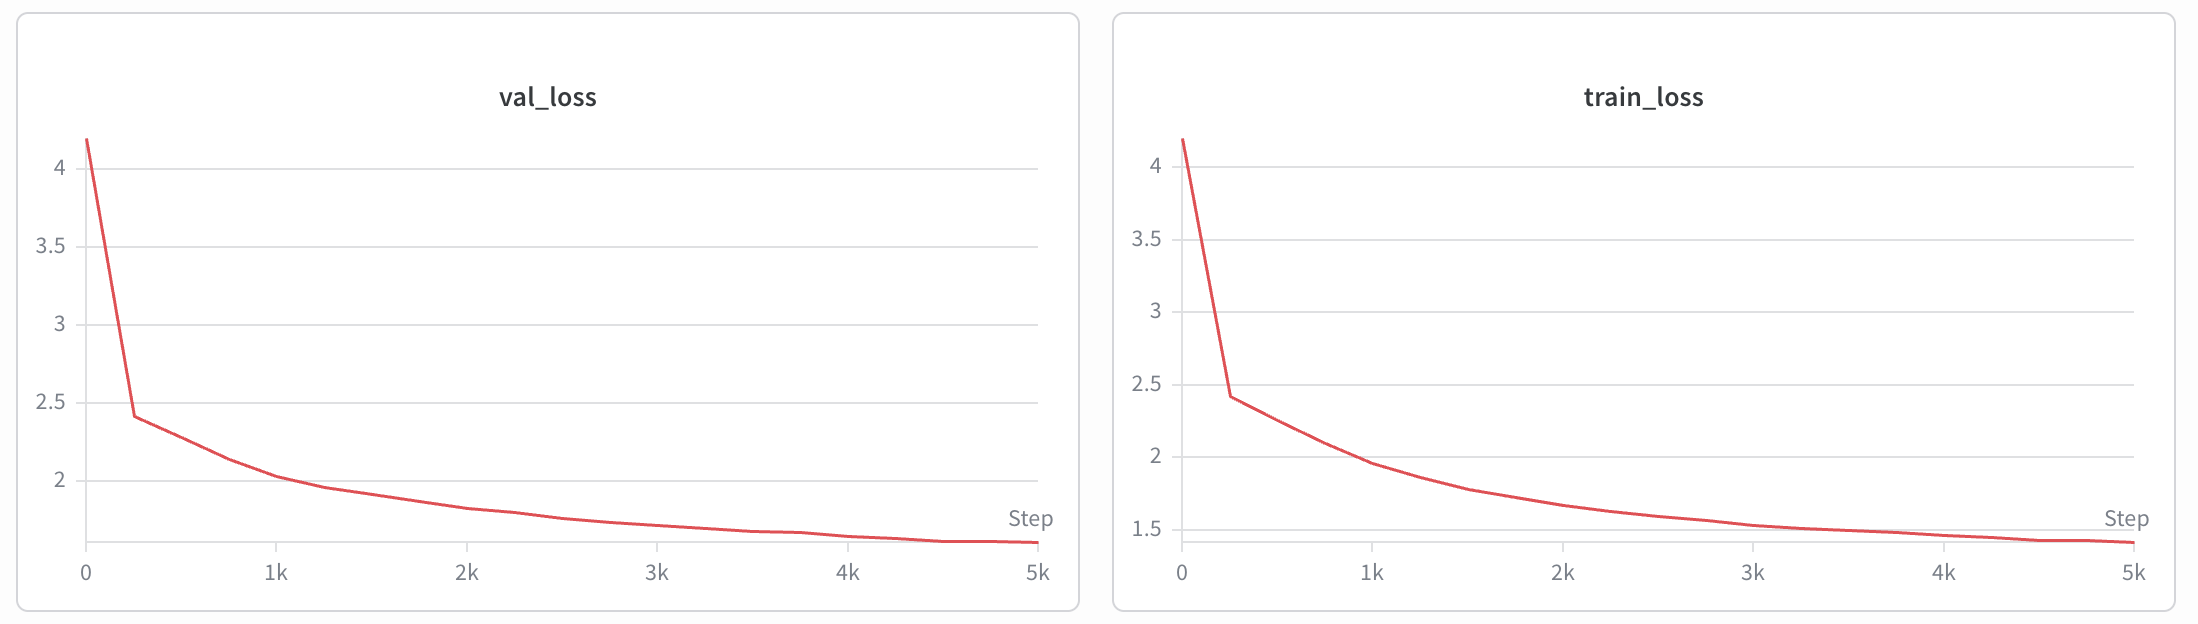

We see a gradual improvement in loss across 5,000 epochs. I chose this as it was around 5,000 epochs that the improvements started to asymptote.

### Discussion of what affects performance

#### Model size

I found that increasing the number of blocks improved performance up to a point, but the upper bound of the signal that could be learned was dependent on the tokenization choice. I used n=4 transformer blocks.

If I used more blocks, it would be more able to model more complex patterns. However, training would be slower per epoch and GPU memory usage would be larger. We'd also have a higher overfitting risk since the Tiny Shakespeare corpus is so small. However, If I used fewer blocks, we'd see faster and cheaper training, but lower expressive power. I found n=4 blocks to work pretty well.

#### Context length

I chose to use context length = 128 tokens. This likely helps to traint he model well, as even though we use a simple tokenization scheme, we have a pretty large context window. A larger context length means the model can use longer-range context (e.g., stylistic patterns across longer spans), but at the cost of increased GPU memory usage. I found context length = 128 to work well.

#### Training time

I chose to run it for 5,000 epochs. I found performance to improve gradually over time, up until around this number of epochs. It did continue to improve past 5,000 epochs but performance was sufficient for pedagogical purposes here. Notably, we see improvement in both training and validation loss curves; we would've been concerned about overfitting if we saw that the training loss improved but validation loss did not (or in fact got worse).

#### Tokenization

I used character-level tokenization (like the original NanoGPT implementation). This is very naive and simple to implement, but doesn't include larger units of tokens and each with different meanings. We could've explored something more cutting-edge like BPE or other encoding methods, but this tokenization method matches the original NanoGPT implementation and replicates the simple proof of concept. A more robust tokenization scheme would've likely improved generation quality and training because we can encode more meaning into the input tokens during training.